In [1]:
import os
import shutil

SOURCE_DIR = "/kaggle/input/datasets/pppiiiy/vangrove-v2/balanced_700/balanced"

OUTPUT_DIR = "/kaggle/working/multiclass_dataset"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

for plant in os.listdir(SOURCE_DIR):

    plant_path = os.path.join(
        SOURCE_DIR,
        plant
    )

    for disease in os.listdir(plant_path):

        disease_path = os.path.join(
            plant_path,
            disease
        )

        new_class_name = (
            f"{plant}_{disease}"
        )

        output_class_path = os.path.join(
            OUTPUT_DIR,
            new_class_name
        )

        os.makedirs(
            output_class_path,
            exist_ok=True
        )

        for file in os.listdir(disease_path):

            src = os.path.join(
                disease_path,
                file
            )

            dst = os.path.join(
                output_class_path,
                file
            )

            shutil.copy(
                src,
                dst
            )

print("DONE")

DONE


In [2]:
import shutil

shutil.rmtree(
    "/kaggle/working/multiclass_dataset/balanced_tomato",
    ignore_errors=True
)

print("REMOVED")

REMOVED


2026-05-17 09:40:11.207243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779010811.418735      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779010811.486959      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779010811.993207      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779010811.993241      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779010811.993244      57 computation_placer.cc:177] computation placer alr

Found 17532 files belonging to 27 classes.
Using 14026 files for training.


I0000 00:00:1779010841.590753      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779010841.596912      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17532 files belonging to 27 classes.
Using 3506 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EPOCH 1/20


E0000 00:00:1779010979.801909      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779010982.281710     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
E0000 00:00:1779011099.455608      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Train Loss : 1.9864
Train Acc  : 0.4303
Val Loss   : 1.1035
Val Acc    : 0.6341
MODEL SAVED
EPOCH 2/20
Train Loss : 1.2045
Train Acc  : 0.6153
Val Loss   : 0.9099
Val Acc    : 0.6962
MODEL SAVED
EPOCH 3/20
Train Loss : 1.0230
Train Acc  : 0.6673
Val Loss   : 0.8150
Val Acc    : 0.7296
MODEL SAVED
EPOCH 4/20
Train Loss : 0.9126
Train Acc  : 0.6983
Val Loss   : 0.7404
Val Acc    : 0.7507
MODEL SAVED
EPOCH 5/20
Train Loss : 0.8444
Train Acc  : 0.7206
Val Loss   : 0.7115
Val Acc    : 0.7627
MODEL SAVED
EPOCH 6/20
Train Loss : 0.7981
Train Acc  : 0.7319
Val Loss   : 0.6970
Val Acc    : 0.7698
MODEL SAVED
EPOCH 7/20
Train Loss : 0.7431
Train Acc  : 0.7475
Val Loss   : 0.6710
Val Acc    : 0.7764
MODEL SAVED
EPOCH 8/20
Train Loss : 0.7088
Train Acc  : 0.7586
Val Loss   : 0.6587
Val Acc    : 0.7807
MODEL SAVED
EPOCH 9/20
Train Loss : 0.6859
Train Acc  : 0.7663
Val Loss   : 0.6385
Val Acc    : 0.7841
MODEL SAVED
EPOCH 10/20
Train Loss : 0.6716
Train Acc  : 0.7731
Val Loss   : 0.6274
Val Acc    :

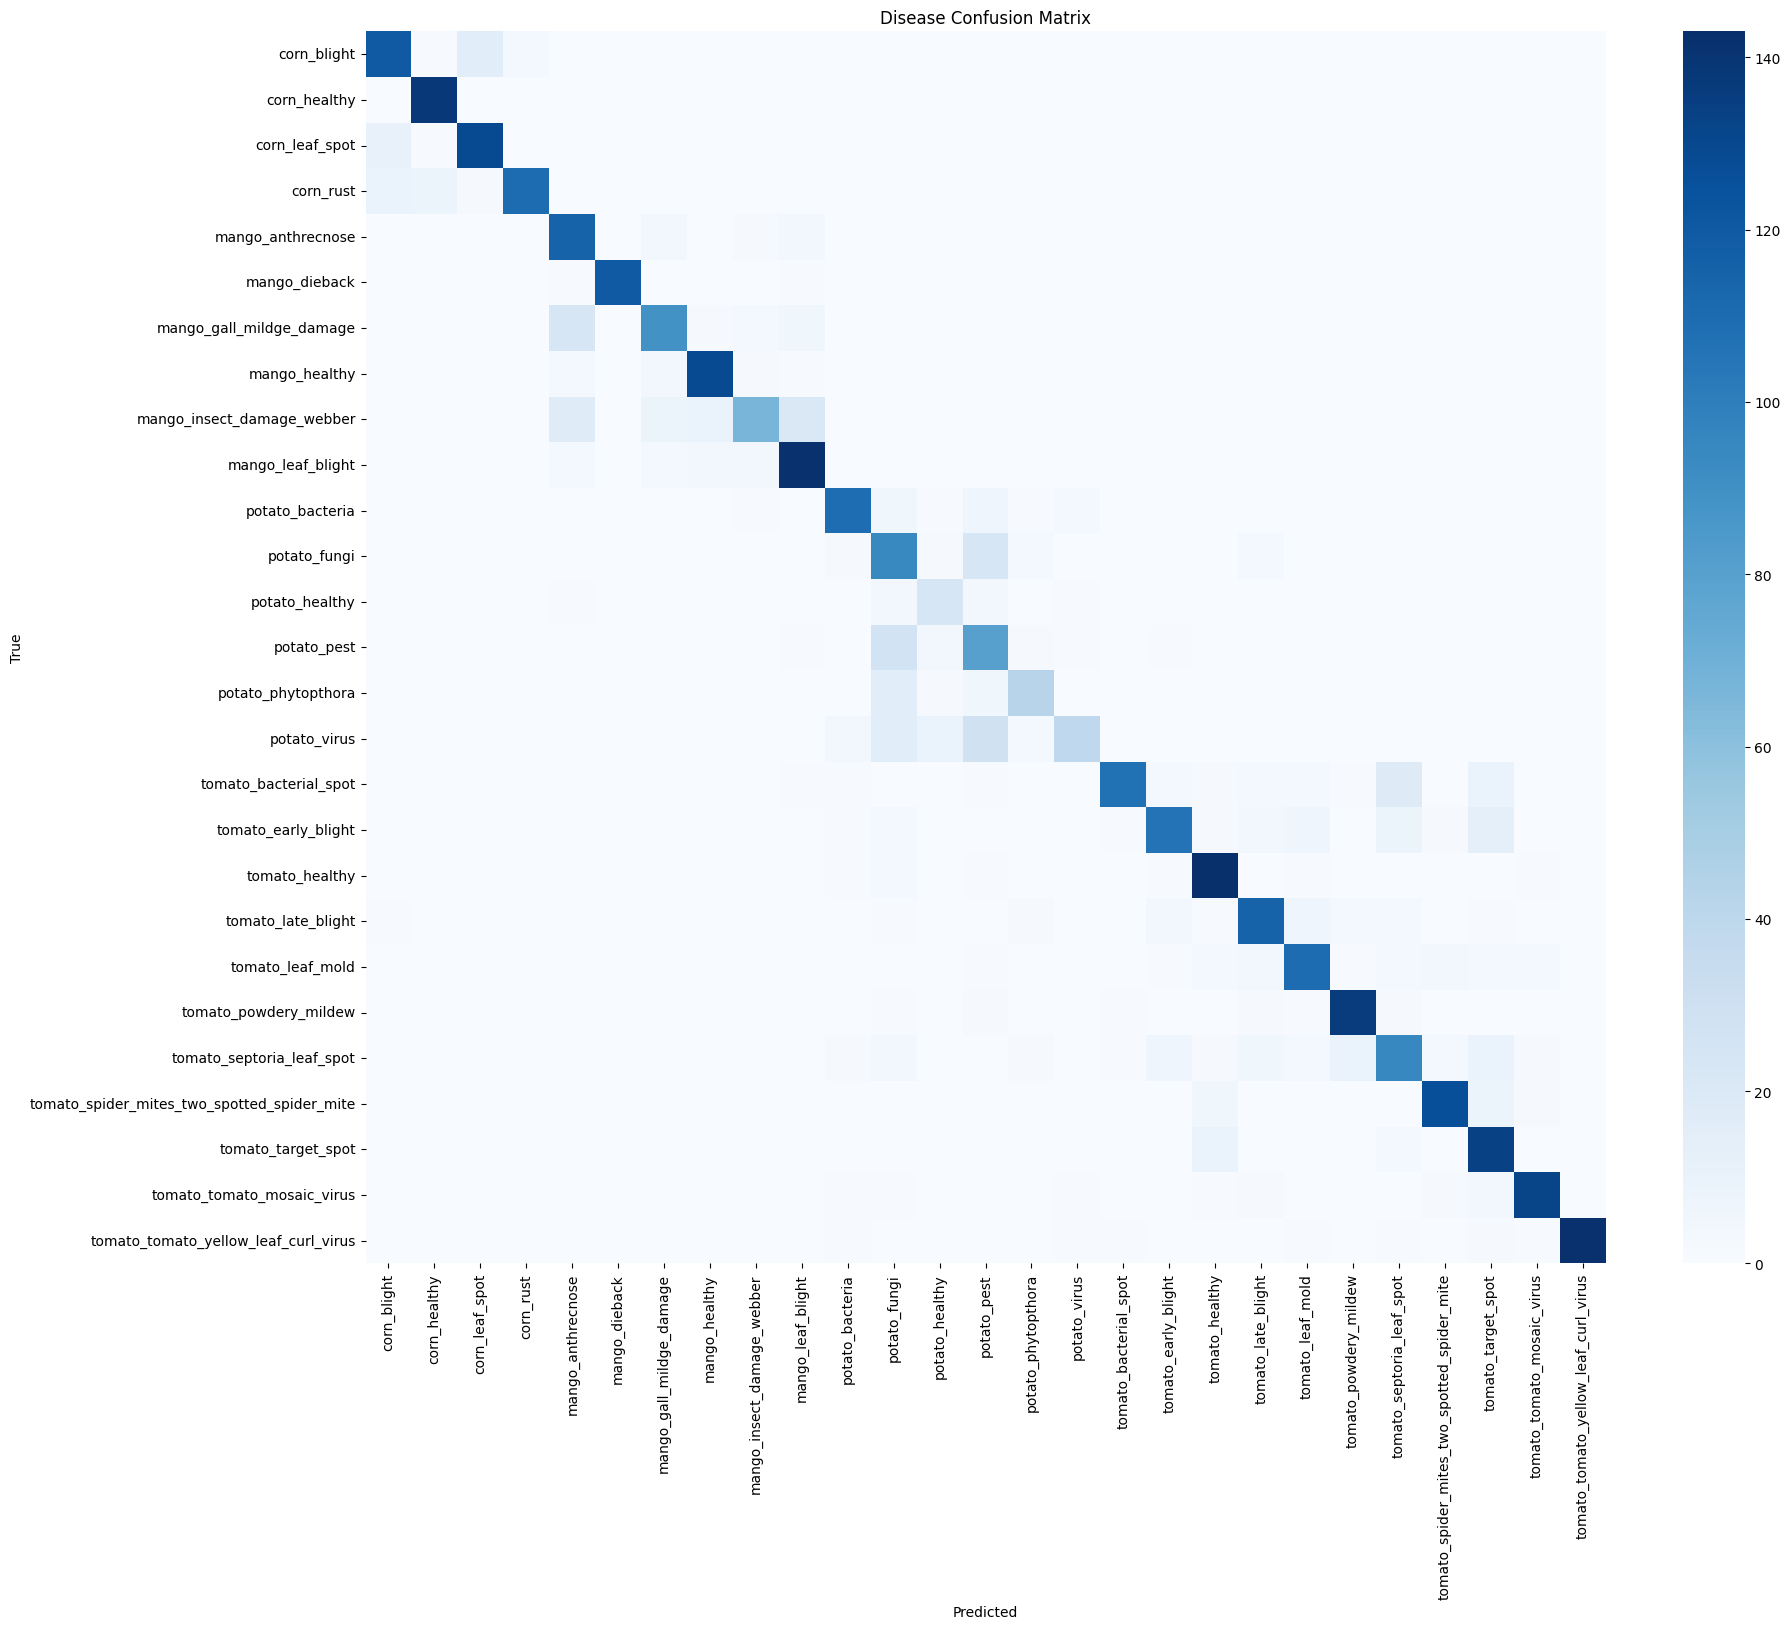

CLASS NAMES SAVED


<IPython.core.display.Javascript object>

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import pickle
import random
import datetime

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import (
    compute_class_weight
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = "/kaggle/working/multiclass_dataset"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

y_train = []

for _, labels in train_ds:
    y_train.extend(np.argmax(labels.numpy(), axis=1))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

class RandomBackground(tf.keras.layers.Layer):

    def call(self, images):

        images = tf.cast(images, tf.float32)

        gray = tf.reduce_mean(
            images,
            axis=-1,
            keepdims=True
        )

        mask = tf.cast(gray > 240, tf.float32)

        random_bg = tf.random.uniform(
            tf.shape(images),
            0,
            255
        )

        images = (
            images * (1-mask)
            +
            random_bg * mask
        )

        return images

random_bg = RandomBackground()

augment = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.15),

    tf.keras.layers.RandomZoom(0.15),

    tf.keras.layers.RandomContrast(0.2),

    tf.keras.layers.RandomBrightness(0.2),

    tf.keras.layers.RandomTranslation(0.1, 0.1),

    tf.keras.layers.GaussianNoise(0.03)

])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = augment(inputs)

x = random_bg(x)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

loss_fn = tf.keras.losses.CategoricalCrossentropy()

optimizer = tf.keras.optimizers.Adam(1e-4)

train_acc_metric = tf.keras.metrics.CategoricalAccuracy()

val_acc_metric = tf.keras.metrics.CategoricalAccuracy()

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(log_dir)

best_val_acc = 0
patience = 4
wait = 0

@tf.function

def train_step(images, labels):

    with tf.GradientTape() as tape:

        predictions = model(images, training=True)

        loss = loss_fn(labels, predictions)

    grads = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    train_acc_metric.update_state(
        labels,
        predictions
    )

    return loss

@tf.function

def val_step(images, labels):

    predictions = model(images, training=False)

    v_loss = loss_fn(labels, predictions)

    val_acc_metric.update_state(
        labels,
        predictions
    )

    return v_loss

for epoch in range(EPOCHS):

    print(f"EPOCH {epoch+1}/{EPOCHS}")

    train_losses = []
    val_losses = []

    for images, labels in train_ds:

        loss = train_step(images, labels)

        train_losses.append(loss.numpy())

    for images, labels in val_ds:

        v_loss = val_step(images, labels)

        val_losses.append(v_loss.numpy())

    train_acc = train_acc_metric.result().numpy()
    val_acc = val_acc_metric.result().numpy()

    print(f"Train Loss : {np.mean(train_losses):.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {np.mean(val_losses):.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    with summary_writer.as_default():

        tf.summary.scalar(
            'train_loss',
            np.mean(train_losses),
            step=epoch
        )

        tf.summary.scalar(
            'train_acc',
            train_acc,
            step=epoch
        )

        tf.summary.scalar(
            'val_loss',
            np.mean(val_losses),
            step=epoch
        )

        tf.summary.scalar(
            'val_acc',
            val_acc,
            step=epoch
        )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        wait = 0

        model.save("best_model.keras")

        print("MODEL SAVED")

    else:

        wait += 1

        print(f"WAIT : {wait}/{patience}")

        if wait >= patience:

            print("EARLY STOPPING")

            break

    train_acc_metric.reset_state()
    val_acc_metric.reset_state()

y_true = []
y_pred = []

for images, labels in val_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_pred.extend(np.argmax(preds, axis=1))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20,16))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Disease Confusion Matrix")

plt.show()

with open(
    "class_names.pkl",
    "wb"
) as f:

    pickle.dump(class_names, f)

print("CLASS NAMES SAVED")

model.save("best_model.keras")

%load_ext tensorboard
%tensorboard --logdir logs/fit

In [4]:
base_model.trainable = True

for layer in base_model.layers[:-30]:

    layer.trainable = False

optimizer = tf.keras.optimizers.Adam(
    5e-5
)

EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):

    print(f"\nFINE TUNE EPOCH {epoch+1}/{EPOCHS_FINE}")

    train_losses = []
    val_losses = []

    for images, labels in train_ds:

        with tf.GradientTape() as tape:

            predictions = model(
                images,
                training=True
            )

            loss = loss_fn(
                labels,
                predictions
            )

        grads = tape.gradient(
            loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                grads,
                model.trainable_variables
            )
        )

        train_acc_metric.update_state(
            labels,
            predictions
        )

        train_losses.append(
            loss.numpy()
        )

    for images, labels in val_ds:

        predictions = model(
            images,
            training=False
        )

        v_loss = loss_fn(
            labels,
            predictions
        )

        val_acc_metric.update_state(
            labels,
            predictions
        )

        val_losses.append(
            v_loss.numpy()
        )

    train_acc = train_acc_metric.result().numpy()

    val_acc = val_acc_metric.result().numpy()

    print(
        f"Train Loss : {np.mean(train_losses):.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.4f}"
    )

    print(
        f"Val Loss   : {np.mean(val_losses):.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.4f}"
    )

    train_acc_metric.reset_state()

    val_acc_metric.reset_state()


FINE TUNE EPOCH 1/5
Train Loss : 0.8215
Train Acc  : 0.7316
Val Loss   : 0.6154
Val Acc    : 0.7963

FINE TUNE EPOCH 2/5
Train Loss : 0.6288
Train Acc  : 0.7850
Val Loss   : 0.5521
Val Acc    : 0.8118

FINE TUNE EPOCH 3/5
Train Loss : 0.5353
Train Acc  : 0.8158
Val Loss   : 0.5022
Val Acc    : 0.8326

FINE TUNE EPOCH 4/5
Train Loss : 0.4871
Train Acc  : 0.8305
Val Loss   : 0.4680
Val Acc    : 0.8411

FINE TUNE EPOCH 5/5
Train Loss : 0.4489
Train Acc  : 0.8444
Val Loss   : 0.4564
Val Acc    : 0.8440


In [5]:
from IPython.display import FileLink

# SALAH (Link akan menghasilkan eror 404):
# FileLink(r'/kaggle/working/hasil_model_besar.h5')

# BENAR (Hanya tulis nama file atau folder di dalam direktori kerja):
FileLink(r'best_model.keras')


/kaggle/working/best_model.keras

In [6]:
model.save("best_model_finetune.keras")

In [7]:
FileLink(r'best_model_finetune.keras')

/kaggle/working/best_model_finetune.keras